<a href="https://colab.research.google.com/github/M339KUMAR/QSkillAIMLSeptOct2026/blob/main/Task1/QSkillAIMLSeptOct14-6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

####Email Classification

In [ ]:

from datasets import load_dataset

ds = load_dataset("hossein20s/enrun-emails-text-classification")

dataset_infos.json:   0%|          | 0.00/912 [00:00<?, ?B/s]

data/train-00000-of-00001-b645479548dc21(…): reconstructing file:   0%|          |  0.00B / 6.42MB            

data/train-00000-of-00001-b645479548dc21(…): downloading bytes:           |  0.00B            

data/validation-00000-of-00001-fd3da8083(…): reconstructing file:   0%|          |  0.00B / 1.39MB            

data/validation-00000-of-00001-fd3da8083(…): downloading bytes:           |  0.00B            

data/test-00000-of-00001-92979598d5caa79(…): reconstructing file:   0%|          |  0.00B / 1.40MB            

data/test-00000-of-00001-92979598d5caa79(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/14459 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3104 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3099 [00:00<?, ? examples/s]

In [ ]:

ds["train"].to_csv("email_enrun_train.csv")
ds["test"].to_csv("email_enrun_test.csv")
ds["validation"].to_csv("email_enrun_valid.csv")

Creating CSV from Arrow format:   0%|          | 0/15 [00:00<?, ?ba/s]

Creating CSV from Arrow format:   0%|          | 0/4 [00:00<?, ?ba/s]

Creating CSV from Arrow format:   0%|          | 0/4 [00:00<?, ?ba/s]

2844579

In [ ]:
ds['train']

Dataset({
    features: ['label', 'text'],
    num_rows: 14459
})

In [ ]:
ds['test']

Dataset({
    features: ['label', 'text'],
    num_rows: 3099
})

In [ ]:
ds['validation']

Dataset({
    features: ['label', 'text'],
    num_rows: 3104
})

###Email Classification

In [33]:

import re
import string

import pandas as pd
import nltk
from nltk.corpus import stopwords

In [34]:

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

In [35]:
nltk.download("stopwords", quiet=True)
STOPWORDS = set(stopwords.words("english"))

In [36]:
len(STOPWORDS)

198

In [37]:
#ingest the dataset into the program
train_ds ='/content/sample_data/email_enrun_train.csv'
test_ds  ='/content/sample_data/email_enrun_test.csv'
valid_ds ='/content/sample_data/email_enrun_valid.csv'

In [38]:
train_df= pd.read_csv(train_ds)
test_df= pd.read_csv(test_ds)
valid_df= pd.read_csv(valid_ds)

In [39]:
train_df.shape

(14459, 2)

In [40]:
test_df.shape

(3099, 2)

In [41]:
valid_df.shape

(3104, 2)

In [42]:
14459+3099+3104

20662

In [43]:
display(train_df.sample(1))
display(test_df.sample(1))
display(valid_df.sample(1))

,label,text
9083,1,"Nicole Nunn Business Analyst , Digital Quality..."


,label,text
522,1,Des Munro Home Fabrics Operations Director T +...


,label,text
3006,0,"Luis , Can you please submit this broker packa..."


In [44]:
DATA_PATH = pd.concat(
    [train_df, test_df, valid_df],
    ignore_index=True
)

In [45]:
DATA_PATH.shape

(20662, 2)

In [46]:
DATA_PATH["label"].value_counts() #balanced
# 1-----> spam
# 0-----> ham

,count
label,
1,10372
0,10290


In [47]:
DATA_PATH["text"].duplicated().sum()

np.int64(5581)

In [48]:
20662-5581

15081

In [49]:
# 1. Load the messages and labels
# ---------------------------------------------------------------------

def load_data(path) -> pd.DataFrame:

    """
    Loads the dataset and returns a DataFrame with columns: label, message.
    Handles both the raw UCI TSV format and the common Kaggle CSV format
    (v1/v2 columns, latin-1 encoded).
    """

    try:

        # Kaggle-style CSV: columns v1 (label), v2 (message), extra junk cols
        #df = pd.read_csv(path, encoding="latin-1")

        if {"v1", "v2"}.issubset(path.columns):
            path = path[["v1", "v2"]].rename(columns={"v1": "label", "v2": "message"})
        elif {"label", "message"}.issubset(path.columns):
            path = path[["label", "message"]]
        elif {"label", "text"}.issubset(path.columns):
            path = path[["label", "text"]].rename(columns={"label": "label", "text": "message"})
            path["label"] = path["label"].map({ 0:"ham", 1:"spam"})
        else:
            raise ValueError("Unrecognized column format")

    except Exception:

        # Fall back to raw UCI tab-separated format (no header)
        df = pd.read_csv(path, sep="\t", header=None, names=["label", "message"])

    df = path.dropna(subset=["label", "message"]).drop_duplicates()
    return df

In [50]:
# 2. Preprocess the text
# ---------------------------------------------------------------------

def preprocess_text(text: str) -> str:

    """Lowercase, strip punctuation/numbers,
    remove stopwords, tokenize."""

    text = text.lower()

    # remove numbers/punctuation
    text = re.sub(r"[^a-z\s]", " ", text)

    # simple tokenization
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]

    return " ".join(tokens)

In [55]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# 3-6. Full pipeline: vectorize, split, train, evaluate
# --------------------------------------------------------------------

def main():

    print("Loading data...")
    df = load_data(DATA_PATH)

    print("Preprocessing text...")
    df["clean_message"] = df["message"].apply(preprocess_text)
    print('hi')

    df["label"] = df["label"].str.lower().map({"ham": 0, "spam": 1})

    df = df.dropna(subset=["label"])

    print(f"Loaded {len(df)} messages "
          f"({(df['label']==1).sum()} spam, {(df['label']==0).sum()} ham)")

    #print("Preprocessing text...")
    #df["clean_message"] = df["message"].apply(preprocess_text)

    print("Vectorizing (TF-IDF)...")
    vectorizer = TfidfVectorizer(max_features=3000)

    X = vectorizer.fit_transform(df["clean_message"])
    y = df["label"]

    print("Splitting train/test sets...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    models = {
        "Naive Bayes": MultinomialNB(),
        "Logistic Regression": LogisticRegression(max_iter=1000),
    }

    for name, model in models.items():
        print(f"\n=== {name} ===")
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        print(f"Accuracy : {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall   : {rec:.4f}")
        print(f"F1 score : {f1:.4f}")

        print("\nClassification report:")
        print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))

        print("Confusion matrix:")
        print(confusion_matrix(y_test, y_pred))

        cm = confusion_matrix(y_test, y_pred)

        disp = ConfusionMatrixDisplay(
               confusion_matrix=cm,
               display_labels=["HAM", "SPAM"]
               )

        disp.plot()

        plt.title(f"{name} - Confusion Matrix")
        plt.xlabel("Predicted Label")
        plt.ylabel("Actual Label")
        plt.show()

        # ------------------------------------------------------------
        # Try it on a few custom examples using the last trained model
        # ------------------------------------------------------------

        #print("\n=== Sample predictions (Logistic Regression) ===")
        print(f"\n=== Sample predictions {name}  ===")

        samples = [
                  "Congratulations! You've won a $1000 gift card. Click here to claim now!",
                  "Hey, are we still meeting for lunch tomorrow?",
                  "URGENT: Your account has been suspended. Verify your details immediately.",
                  ]

        clean_samples = [preprocess_text(s) for s in samples]

        X_samples = vectorizer.transform(clean_samples)

        models["Logistic Regression"].fit(X_train, y_train)
        preds = models["Logistic Regression"].predict(X_samples)
        for text, pred in zip(samples, preds):
            label = "SPAM" if pred == 1 else "HAM"
            print(f"[{label}] {text}")

Loading data...
Preprocessing text...
hi
Loaded 15081 messages (6070 spam, 9011 ham)
Vectorizing (TF-IDF)...
Splitting train/test sets...

=== Naive Bayes ===
Accuracy : 0.9871
Precision: 0.9941
Recall   : 0.9736
F1 score : 0.9838

Classification report:
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1803
        spam       0.99      0.97      0.98      1214

    accuracy                           0.99      3017
   macro avg       0.99      0.98      0.99      3017
weighted avg       0.99      0.99      0.99      3017

Confusion matrix:
[[1796    7]
 [  32 1182]]


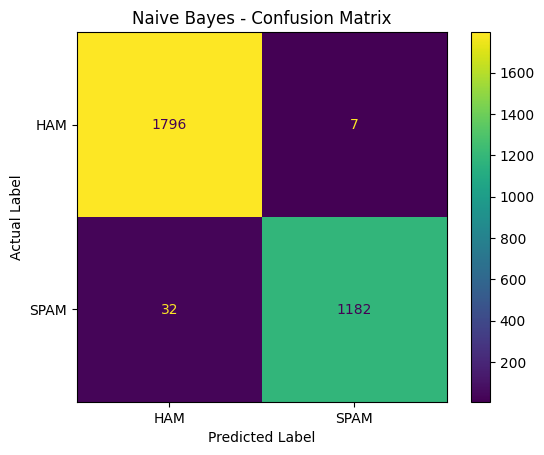


=== Sample predictions Naive Bayes  ===
[HAM] Congratulations! You've won a $1000 gift card. Click here to claim now!
[HAM] Hey, are we still meeting for lunch tomorrow?
[SPAM] URGENT: Your account has been suspended. Verify your details immediately.

=== Logistic Regression ===
Accuracy : 0.9911
Precision: 0.9806
Recall   : 0.9975
F1 score : 0.9890

Classification report:
              precision    recall  f1-score   support

         ham       1.00      0.99      0.99      1803
        spam       0.98      1.00      0.99      1214

    accuracy                           0.99      3017
   macro avg       0.99      0.99      0.99      3017
weighted avg       0.99      0.99      0.99      3017

Confusion matrix:
[[1779   24]
 [   3 1211]]


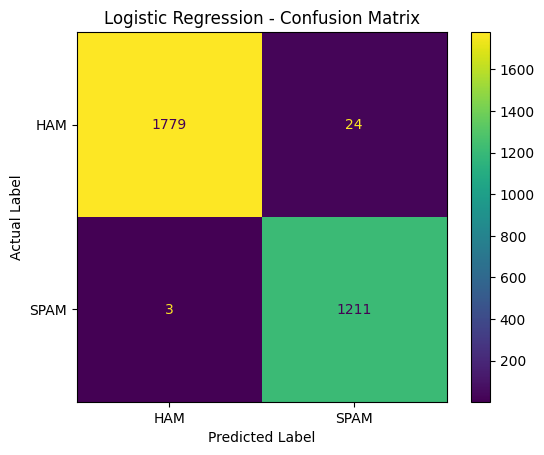


=== Sample predictions Logistic Regression  ===
[HAM] Congratulations! You've won a $1000 gift card. Click here to claim now!
[HAM] Hey, are we still meeting for lunch tomorrow?
[SPAM] URGENT: Your account has been suspended. Verify your details immediately.


In [56]:
if __name__ == "__main__":
     main()